In [1]:
import geopandas as gpd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from shapely.vectorized import contains

In [2]:
regions = gpd.read_file("../data/GIS/forecasting_regions_wgs84.geojson")
print(regions.columns)
print("Unique names example:", list(regions["name"].unique())[:10])


Index(['id', 'name', 'safeName', 'regionType', 'geometry'], dtype='str')
Unique names example: ['Agder sør', 'Akershus', 'Buskerud sør', 'Finnmarkskysten', 'Finnmarksvidda', 'Hallingdal', 'Hardanger', 'Hedmark', 'Heiane', 'Helgeland']


In [3]:
jotun = regions[regions["name"] == "Jotunheimen"]
print("Antall rader (skal være 1):", len(jotun))

poly = jotun.geometry.values[0]
print("Polygon type:", type(poly))

Antall rader (skal være 1): 1
Polygon type: <class 'shapely.geometry.multipolygon.MultiPolygon'>


In [4]:
fsm2 = xr.open_dataset("../data/FSM2/fsm2_sd_2023.nc")

In [5]:
minx, miny, maxx, maxy = poly.bounds  # (lon_min, lat_min, lon_max, lat_max)

fsm2_small = fsm2.where(
    (fsm2["lon"] >= minx) & (fsm2["lon"] <= maxx) &
    (fsm2["lat"] >= miny) & (fsm2["lat"] <= maxy),
    drop=True
)


In [6]:
lat = fsm2_small["lat"].values
lon = fsm2_small["lon"].values
mask = contains(poly, lon, lat)

/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_33755/557916947.py:3: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = contains(poly, lon, lat)


In [7]:
mask_da = xr.DataArray(
    mask,
    dims=("y", "x"),
    coords={"y": fsm2_small["y"], "x": fsm2_small["x"]},
    name="jotun_mask"
)

In [8]:
fsm2_jotun = fsm2_small.where(mask_da)

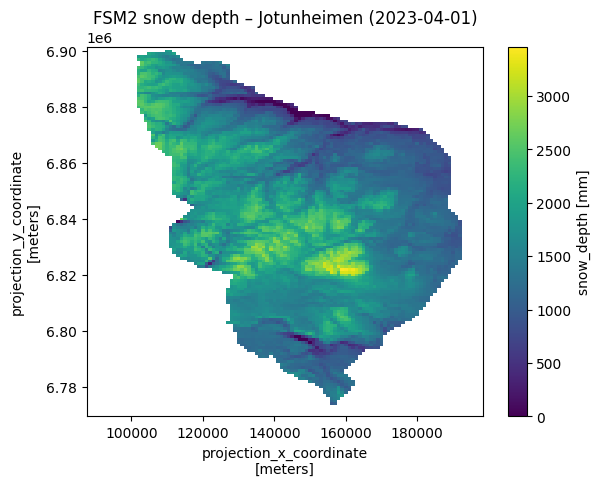

In [9]:
fsm2_jotun["snow_depth"].sel(time="2023-04-01").plot()
plt.title("FSM2 snow depth – Jotunheimen (2023-04-01)")
plt.show()

In [10]:
sen = xr.open_dataset("../data/seNorge/sd_2023.nc")
print("seNorge vars:", list(sen.data_vars))

seNorge vars: ['snow_depth', 'UTM_Zone_33']


In [11]:
sen_var = list(sen.data_vars)[0]  # eller sett eksplisitt, f.eks. "snow_depth"

In [12]:
# Pre-clip med bounding box (samme poly)
minx, miny, maxx, maxy = poly.bounds

sen_small = sen.where(
    (sen["lon"] >= minx) & (sen["lon"] <= maxx) &
    (sen["lat"] >= miny) & (sen["lat"] <= maxy),
    drop=True
)

lat_s = sen_small["lat"].values
lon_s = sen_small["lon"].values

mask_s = contains(poly, lon_s, lat_s)

mask_s_da = xr.DataArray(
    mask_s,
    dims=("y", "x"),
    coords={"y": sen_small["y"], "x": sen_small["x"]},
    name="jotun_mask"
)

sen_jotun = sen_small.where(mask_s_da)

/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_33755/2209458286.py:13: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask_s = contains(poly, lon_s, lat_s)


seNorge units: cm


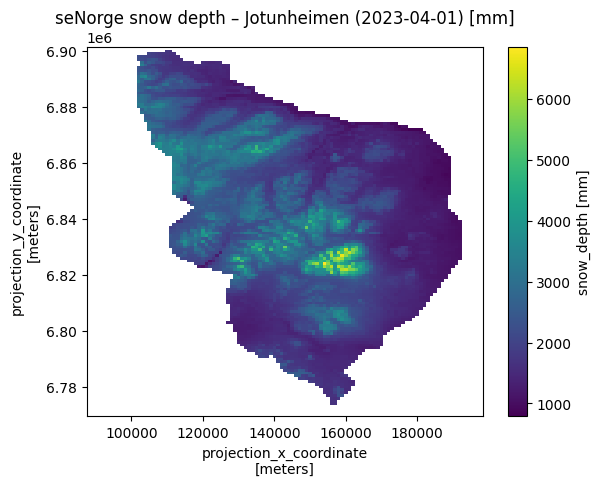

In [13]:
# Sjekk units
print("seNorge units:", sen_jotun[sen_var].attrs.get("units"))

# Konverter til mm hvis cm
sen_sd_mm = sen_jotun[sen_var]
if sen_sd_mm.attrs.get("units") == "cm":
    sen_sd_mm = sen_sd_mm * 10
    sen_sd_mm.attrs["units"] = "mm"

sen_sd_mm.sel(time="2023-04-01").plot()
plt.title("seNorge snow depth – Jotunheimen (2023-04-01) [mm]")
plt.show()

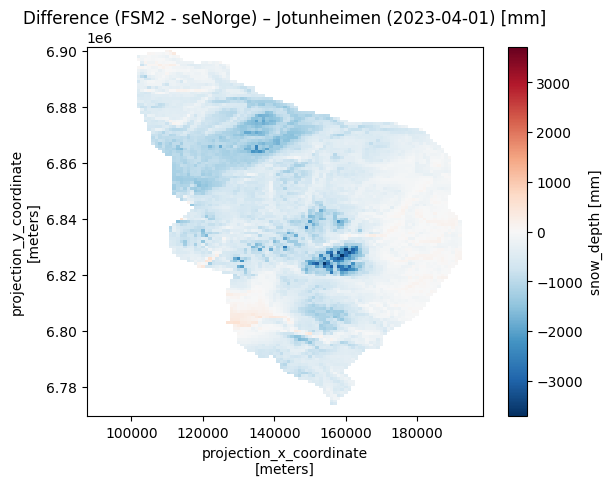

In [14]:
fsm_day = fsm2_jotun["snow_depth"].sel(time="2023-04-01")

sen_day = sen_sd_mm.sel(time="2023-04-01")

# Interpoler seNorge (lat/lon) til FSM2 sitt lat/lon-grid
sen_on_fsm = sen_day.interp(
    x=fsm2_jotun["x"],
    y=fsm2_jotun["y"],
    method="nearest"
)

diff = fsm_day - sen_on_fsm

diff.plot()
plt.title("Difference (FSM2 - seNorge) – Jotunheimen (2023-04-01) [mm]")
plt.show()

In [15]:
print("Mean diff (mm):", float(diff.mean()))
print("Median diff (mm):", float(diff.median()))
print("Min/Max diff (mm):", float(diff.min()), float(diff.max()))

Mean diff (mm): -542.185791015625
Median diff (mm): -487.0
Min/Max diff (mm): -3718.0 575.0


In [16]:
print(sen_on_fsm)
print("dims:", sen_on_fsm.dims)

<xarray.DataArray 'snow_depth' (y: 132, x: 111)> Size: 59kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(132, 111), dtype=float32)
Coordinates:
  * y        (y) float64 1kB 6.77e+06 6.771e+06 6.772e+06 ... 6.9e+06 6.901e+06
  * x        (x) float64 888B 8.8e+04 8.9e+04 9e+04 ... 1.97e+05 1.98e+05
    lon      (y, x) float64 117kB 7.406 7.425 7.443 7.461 ... 9.168 9.187 9.206
    lat      (y, x) float64 117kB 60.85 60.85 60.85 60.85 ... 62.12 62.12 62.12
    time     datetime64[ns] 8B 2023-04-01
Attributes:
    Name:           snow_depth
    grid_mapping:   UTM_Zone_33
    name:           sd
    units:          mm
    standard_name:  snow_depth
    longname:       snow depth
dims: ('y', 'x')


In [17]:
sen_sd = sen_jotun[sen_var]   # dette skal være (time, y, x)

print("sen_sd dims:", sen_sd.dims)
print("sen_sd units:", sen_sd.attrs.get("units"))

if sen_sd.attrs.get("units") == "cm":
    sen_sd = sen_sd * 10
    sen_sd.attrs["units"] = "mm"

sen_sd dims: ('time', 'y', 'x')
sen_sd units: cm


In [18]:
sen_on_fsm_all = sen_sd.interp(
    x=fsm2_jotun["x"],
    y=fsm2_jotun["y"],
    method="nearest"
)

print(sen_on_fsm_all)
print("dims:", sen_on_fsm_all.dims)

<xarray.DataArray 'snow_depth' (time: 365, y: 132, x: 111)> Size: 21MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, .

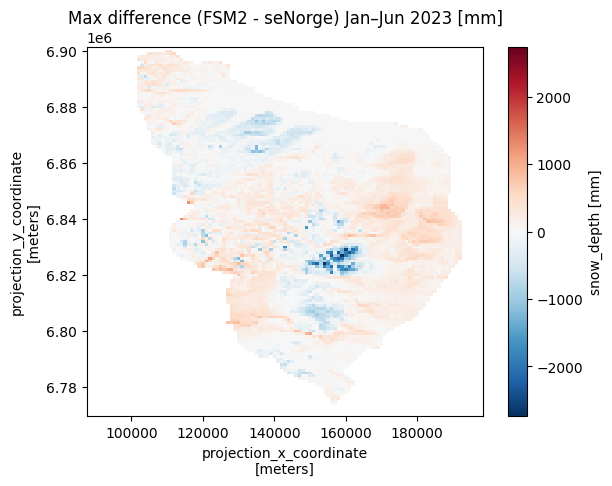

In [19]:
winter_fsm = fsm2_jotun["snow_depth"].sel(time=slice("2023-01-01","2023-06-30"))
winter_sen = sen_on_fsm_all.sel(time=slice("2023-01-01","2023-06-30"))

diff_winter = winter_fsm - winter_sen

# eksempel: maks differanse i perioden
diff_max = diff_winter.max(dim="time")
diff_max.plot()
plt.title("Max difference (FSM2 - seNorge) Jan–Jun 2023 [mm]")
plt.show()

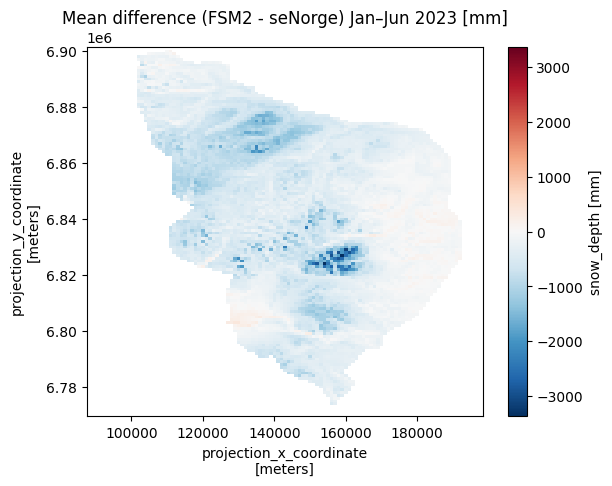

In [20]:
diff_mean = diff_winter.mean(dim="time")
diff_mean.plot()
plt.title("Mean difference (FSM2 - seNorge) Jan–Jun 2023 [mm]")
plt.show()

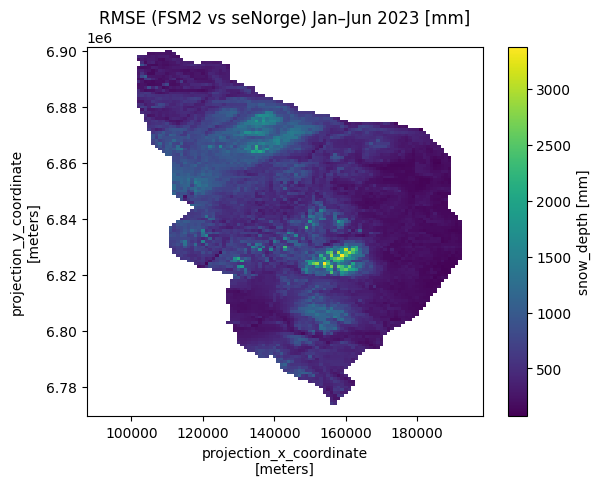

In [21]:
diff_rmse = np.sqrt((diff_winter**2).mean(dim="time"))
diff_rmse.plot()
plt.title("RMSE (FSM2 vs seNorge) Jan–Jun 2023 [mm]")
plt.show()